Utilizzando il dataset Iris, replicare l'esercitazione pratica in Python
    - Effettuare la standarizzazione dei dati
    - Ridurre i dati con PCA a n_components=2
    - Plottare l'Elbow Method della log_likelihood e stabilire il numero k di clusters
    - Addestare il modello GMM usanti i parametri:
        - n.components=K
        - Covariance_type='full'
        - random_state=42
    - Effettuare la predizione delle label e stamparla
    - Plottare i dati originali del dataset ridotta con la PCA
    - Fare la conversione tra y reali e labels assegnate dal GMM
    - Calcolare l'accuracy del Clustering con GMM in percentuale

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

Importo il dataset

In [2]:
data=load_iris()
X,y=data.data,data.target
target_names=data.target_names

- Effettuare la standarizzazione dei dati

In [3]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

- Ridurre i dati con PCA a n_components=2

In [4]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_std)

- Plottare l'Elbow Method della log_likelihood e stabilire il numero k di clusters

In [7]:
bic_values=[]
aic_values=[]
log_likelihood=[]
k_values = range(1, 10)
for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X_std)
        bic_values.append(gmm.bic(X_std))
        aic_values.append(gmm.aic(X_std))
        log_likelihood.append(gmm.score(X_std))
print("k | score | improvement | AIC | BIC")
for i, (k, s, a, b) in enumerate(zip(k_values, log_likelihood, aic_values, bic_values)):
    if i == 0:
        improvement = 0 #non ha confronto
    else:
        improvement = s - log_likelihood[i-1]
    print(f"{k} | {s:.4f} | {improvement:.4f} | {a:.2f} | {b:.2f}")

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

k | score | improvement | AIC | BIC
1 | -3.2684 | 0.0000 | 1008.52 | 1050.67
2 | -2.1647 | 1.1037 | 707.40 | 794.71
3 | -2.0691 | 0.0956 | 708.72 | 841.19
4 | -1.8456 | 0.2235 | 671.67 | 849.30
5 | -1.7692 | 0.0764 | 678.75 | 901.54
6 | -1.7422 | 0.0270 | 700.66 | 968.61
7 | -1.4472 | 0.2950 | 642.15 | 955.26
8 | -1.4327 | 0.0145 | 667.80 | 1026.07
9 | -1.5264 | -0.0937 | 725.93 | 1129.35


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


BIC suggerisce k=2

C:\Users\uberti\AppData\Local\Temp\ipykernel_32648\1081877156.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


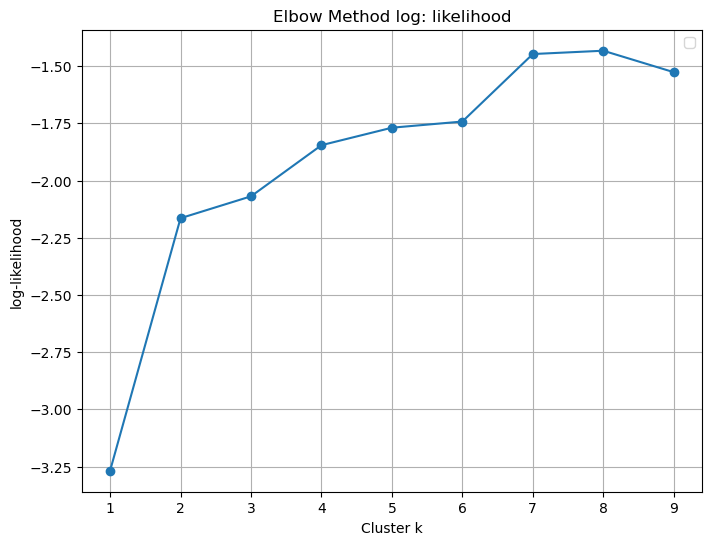

In [9]:
plt.figure(figsize=(8,6))
plt.plot(k_values,log_likelihood,marker='o')
plt.title("Elbow Method log: likelihood")
plt.xlabel("Cluster k")
plt.ylabel("log-likelihood")
plt.grid()
plt.legend()
plt.show()


conferma k=2

In [11]:
best_k=2

- Addestare il modello GMM usanti i parametri:
    - n.components=K
    - Covariance_type='full'
    - random_state=42

In [12]:
gmm=GaussianMixture(n_components=best_k,covariance_type='full',random_state=42)
gmm.fit(X_std)
labels=gmm.predict(X_std)

print(labels.shape)
print(labels)

(150,)
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


quanta informazione è spiegata da ogni componente PCA

In [17]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


PC1 spiega il 72.96%
PC2 spiega il 22.85%
con PC1 e PC2 ottengo il 95% di informazione

- Plottare i dati originali del dataset ridotta con la PCA

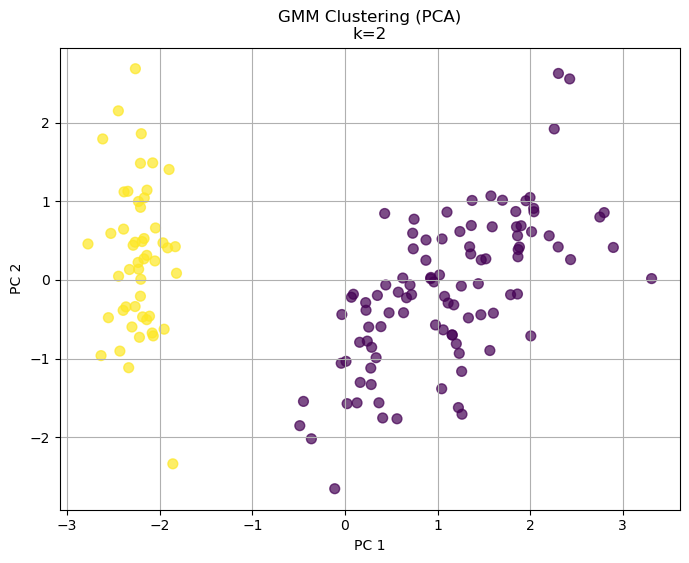

In [16]:

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='viridis',s=50,alpha=0.7)

plt.title(f"GMM Clustering (PCA)\nk={best_k}")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='viridis',s=50,alpha=0.7)
plt.title("GMM Clustering (PCA)\nk={best_k}")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid()
plt.legend()
plt.show()

- Fare la conversione tra y reali e labels assegnate dal GMM (allinea i numeri dei cluster del GMM con le classi reali)

In [18]:
def gmm_accurancy(y_true,y_pred):
    labels=np.zeros_like(y_pred)
    for cluster_id in np.unique(y_pred):
        mask=(cluster_id==y_pred)
        true_labels=y_true[mask]
        if true_labels.size>0:
            most_common=np.bincount(true_labels).argmax()
            labels[mask]=most_common
    return np.mean(labels==y_true)

In [19]:
accuracy=gmm_accurancy(y,labels)
print(f"GMM Clustering accurancy: {accuracy*100}%")

GMM Clustering accurancy: 66.66666666666666%


con k=2, il modello GMM ottiene un'accuratezza del 66,66% indicando che due delle tre classi vengono raggruppate insieme. Questo suggerisce che i dati presentano una struttura naturale a due cluser principali. Tuttavia impostando k=3 il modello riesce a ricostruire accuratamaente le classi originali (96%) evidenziando che la suddivisione in tre clusetr riflette meglio le etichette reali del dataset.
Quindi tenere:
k=2 se vuoi strutturare i dati
k=3 se vuoi ricostruire le classi